# Evaluación 1 - Deep Learning
**Tema:** Clasificación del resultado de partidos de la Primera División de Chile (victoria local / empate / victoria visita)


## 1. Carga de datos

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [ ]:
csv_path = "matches.csv"

try:
    df = pd.read_csv(csv_path, encoding="utf-8")
except UnicodeDecodeError:
    df = pd.read_csv(csv_path, encoding="latin1")

df.head()

,Date,HT,AT,HS,AS
0,21/6/2008,La Serena,Audax Italiano,1,1
1,21/6/2008,Unión Española,Melipilla,1,0
2,22/6/2008,O'Higgins,Universidad de Concepcion,3,3
3,22/6/2008,Antofagasta,Palestino,0,3
4,22/6/2008,Huachipato,Cobreloa,1,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3619 entries, 0 to 3618
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    3619 non-null   object
 1   HT      3619 non-null   object
 2   AT      3619 non-null   object
 3   HS      3619 non-null   int64 
 4   AS      3619 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 141.5+ KB


### Clasificación de las variables

Las variables Date y los nombres de los equipos local (HT) y visitante (AT) corresponden a variables categóricas o de identificación. Las variables HS y AS corresponden a variables numéricas enteras, ya que representan la cantidad de goles anotados por cada equipo.

La variable Resultado, creada posteriormente, corresponde a una variable categórica con tres clases: victoria visitante, empate y victoria local.

## 2. Transformación de los datos y creación de la variable objetivo

Como se acordó para el desarrollo, necesitamos adaptar el problema a lo que pide la evaluación, la cual requiere específicamente resolver un problema de clasificación. Predecir la cantidad exacta de goles que anotará cada equipo correspondería a un problema de regresión. Por lo tanto, vamos a crear una nueva columna llamada 'Resultado' que indicará la clase a predecir: victoria local (2), empate (1) o victoria visita (0).

Después de crear esta variable, procederemos a eliminar las columnas de los goles (HS y AS) y la fecha. Si le entregamos los goles al modelo como variables de entrada, le estaríamos dando la respuesta por adelantado (data leakage), y el objetivo es predecir el resultado basándonos solo en quiénes se enfrentan.

In [ ]:
condiciones = [
    (df['HS'] > df['AS']),
    (df['HS'] == df['AS']),
    (df['HS'] < df['AS'])
]
valores = [2, 1, 0]
df['Resultado'] = np.select(condiciones, valores)

df_limpio = df.drop(columns=['Date', 'HS', 'AS'])

df_limpio.head()

,HT,AT,Resultado
0,La Serena,Audax Italiano,1
1,Unión Española,Melipilla,2
2,O'Higgins,Universidad de Concepcion,1
3,Antofagasta,Palestino,0
4,Huachipato,Cobreloa,0


## 3. Preprocesamiento: Codificación de variables y escalado

Las redes neuronales requieren que todas las entradas sean numéricas. Como nuestros datos contienen los nombres de los equipos en formato string, utilizaremos LabelEncoder para transformarlos a valores numéricos. Es fundamental ajustar el encoder con todos los equipos (juntando local y visita) para que un mismo equipo tenga el mismo ID numérico independientemente de dónde juegue.

Luego, aplicando lo visto en el cuaderno de la clase sobre los puntajes de estudiantes, aplicaremos StandardScaler. Esto nos permite estandarizar los datos, lo cual ayuda a que el algoritmo converja más rápido durante el entrenamiento.

In [ ]:
encoder = LabelEncoder()
todos_los_equipos = pd.concat([df_limpio['HT'], df_limpio['AT']]).unique()
encoder.fit(todos_los_equipos)

df_limpio['HT_encoded'] = encoder.transform(df_limpio['HT'])
df_limpio['AT_encoded'] = encoder.transform(df_limpio['AT'])

X = df_limpio[['HT_encoded', 'AT_encoded']]
y = df_limpio['Resultado']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Muestra de datos escalados:")
print(X_scaled[:5])

Muestra de datos escalados:
[[-0.36138829 -1.47746248]
 [ 1.30666401 -0.25288818]
 [-0.13898131  1.19433601]
 [-1.58462664  0.08108664]
 [-0.58379526 -1.25481261]]


## 4. División de datos (Entrenamiento y Prueba)

Separaremos los datos usando la proporción 80/20 (80% para entrenar la red y 20% para evaluar su desempeño con datos nunca antes vistos). Esto es un paso básico para comprobar que el modelo realmente está generalizando patrones y no simplemente memorizando los datos de entrada.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (2895, 2)
Datos de prueba: (724, 2)


## 5. Construcción de la Red Neuronal Multicapa (MLP)

Para la arquitectura de la red, crearemos un modelo secuencial utilizando Keras. Las decisiones de diseño son las siguientes:

* Capas ocultas: Usaremos capas Dense con función de activación ReLU. Esta función mantiene los valores positivos y transforma en 0 los negativos, lo que ayuda a evitar el problema del gradiente desvaneciente y mejora el entrenamiento.
* Regularización: Incluiremos una capa de Dropout con una tasa de 0.2 como técnica de regularización. Esto apagará aleatoriamente el 20% de las neuronas durante el entrenamiento, ayudando a reducir el riesgo de sobreajuste.
* Capa de salida: Al tratar un problema de clasificación con 3 posibles resultados, usaremos 3 neuronas en la capa de salida junto con la función de activación Softmax, la cual nos entregará una distribución de probabilidades para cada clase.

Para las capas ocultas se utilizaron 32 y 16 neuronas, manteniendo una estructura decreciente y simple. Esta cantidad busca entregar suficiente capacidad para el modelo sin utilizar una arquitectura demasiado grande considerando que solo se utilizan dos variables de entrada.

In [ ]:
import tensorflow as tf

# Fijar semilla para hacer el entrenamiento reproducible
tf.random.set_seed(42)

model = models.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675 (2.64 KB)

 Trainable params: 675 (2.64 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Compilación y Entrenamiento

En esta fase final configuramos cómo aprenderá la red:

* Optimizador: Utilizaremos SGD (Descenso de gradiente estocástico) con una tasa de aprendizaje de 0.01, guiándonos por el caso práctico analizado en clases.
* Función de pérdida: Dejaremos de lado el MSE que utilizábamos en regresión. En su lugar, usaremos sparse_categorical_crossentropy, que es la métrica de error adecuada cuando se trabaja con clasificación de varias clases codificadas como números enteros.

Para el entrenamiento, configuraremos los hiperparámetros clave, definiendo 50 épocas y un tamaño de batch de 32, reservando además un 20% del conjunto de entrenamiento para la validación (validation_split).

In [ ]:
from tensorflow.keras.optimizers import SGD

optimizer = SGD(learning_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Entrenando la red")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Entrenando la red
Epoch 1/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4430 - loss: 1.0824 - val_accuracy: 0.4387 - val_loss: 1.0759
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4508 - loss: 1.0757 - val_accuracy: 0.4387 - val_loss: 1.0753
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4529 - loss: 1.0722 - val_accuracy: 0.4387 - val_loss: 1.0753
Epoch 4/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4581 - loss: 1.0693 - val_accuracy: 0.4387 - val_loss: 1.0755
Epoch 5/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4525 - loss: 1.0722 - val_accuracy: 0.4387 - val_loss: 1.0755
Epoch 6/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4538 - loss: 1.0680 - val_accuracy: 0.4387 - val_loss: 1.0758
Epoch 7/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4486 - loss: 1.0698 - val_accuracy: 0.4387 - val_loss: 1.0758
Epoch 8/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4560 - loss: 1.0693 - val_accuracy: 

## 7. Evaluación del modelo con datos de prueba

Una vez que el modelo ha sido entrenado, debemos evaluar su desempeño real utilizando los datos que separamos al principio (X_test y y_test). Estos datos son nuevos para la red neuronal, por lo que nos indicarán su verdadera capacidad de generalización.

Para esto, utilizaremos la función `predict`, que realizará la propagación hacia adelante (forward pass) sobre los datos de prueba y nos devolverá las probabilidades para cada clase. Luego, usando `np.argmax`, extraeremos la clase con la probabilidad más alta como nuestra predicción final.

Finalmente, generaremos un reporte de clasificación utilizando las herramientas de `sklearn.metrics` para observar la precisión (precision), sensibilidad (recall) y F1-Score de nuestro modelo.

In [ ]:
#Realizar las predicciones con los datos de prueba
y_pred_probabilidades = model.predict(X_test)

#Extraer la clase con mayor probabilidad usando argmax
y_pred_clases = np.argmax(y_pred_probabilidades, axis=1)

#Mostrar el reporte de clasificación detallado
print("Reporte de Clasificación en Datos de Prueba:")
print(classification_report(y_test, y_pred_clases, target_names=['Visita (0)', 'Empate (1)', 'Local (2)']))

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Reporte de Clasificación en Datos de Prueba:
              precision    recall  f1-score   support

  Visita (0)       0.00      0.00      0.00       219
  Empate (1)       0.00      0.00      0.00       174
   Local (2)       0.46      1.00      0.63       331

    accuracy                           0.46       724
   macro avg       0.15      0.33      0.21       724
weighted avg       0.21      0.46      0.29       724



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Análisis de métricas:**
El modelo obtiene un Accuracy de 45,72% en el conjunto de prueba. Sin embargo, al observar las métricas por clase se puede ver que no logra identificar correctamente las victorias visitantes ni los empates, ya que ambas clases presentan valores de Precision, Recall y F1-Score de 0.
La clase Local (2) alcanza un Recall de 1.00, lo que indica que el modelo está prediciendo principalmente esta categoría. Por esta razón, aunque el Accuracy alcanza un 45,72%, el F1-Score ponderado es de 28,69%, mostrando que el modelo tiene dificultades para diferenciar correctamente las tres clases.

## 8. Matriz de Confusión (Mapa de Calor)

Para profundizar en el análisis de los errores presentados en el reporte de clasificación, generaremos una Matriz de Confusión visualizada mediante un mapa de calor.

Esta herramienta nos permite cruzar los valores reales frente a las predicciones del modelo. De esta forma, podemos identificar los falsos positivos y falsos negativos, observando directamente qué categorías presentan mayor nivel de confusión para la red neuronal.

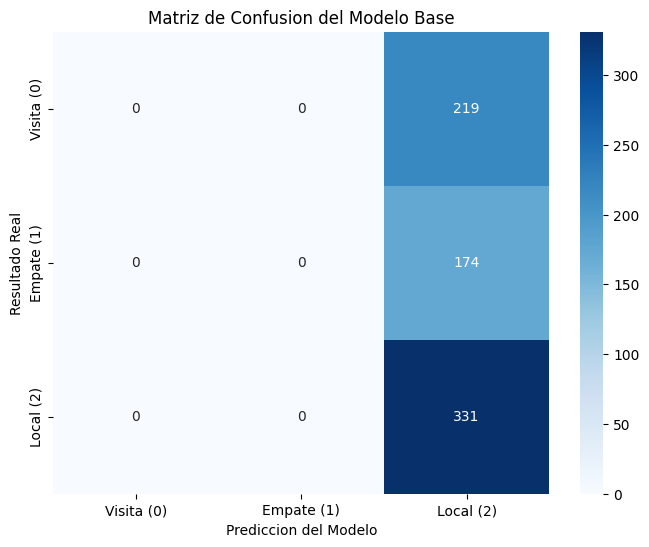

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_clases)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Visita (0)', 'Empate (1)', 'Local (2)'],
            yticklabels=['Visita (0)', 'Empate (1)', 'Local (2)'])

plt.title('Matriz de Confusion del Modelo Base')
plt.xlabel('Prediccion del Modelo')
plt.ylabel('Resultado Real')
plt.show()

**Análisis de la Matriz de Confusión:**
La matriz de confusión muestra que el modelo predice principalmente la clase Local (2), mientras que no logra identificar correctamente las clases Visita (0) y Empate (1).
De los 724 partidos utilizados para prueba, 331 corresponden a victorias locales. Esto explica que el modelo alcance un Accuracy cercano al 46% aun cuando presenta dificultades para distinguir las demás categorías.
Este comportamiento indica que la configuración actual no logra diferenciar adecuadamente las tres clases. Por esta razón, en los siguientes experimentos se modificarán distintos parámetros de entrenamiento, manteniendo constantes los demás, para observar si alguno produce una mejora.

## 9. Visualización del Entrenamiento (Curvas de Pérdida y Accuracy)

Para analizar el comportamiento del modelo a lo largo de las 50 épocas, graficaremos la evolución de la función de pérdida (loss) y la precisión (accuracy), tanto en el conjunto de entrenamiento como en el de validación.

Esto nos permite verificar si el algoritmo de descenso del gradiente está convergiendo adecuadamente y detectar si existe sobreajuste (overfitting) o subajuste (underfitting).

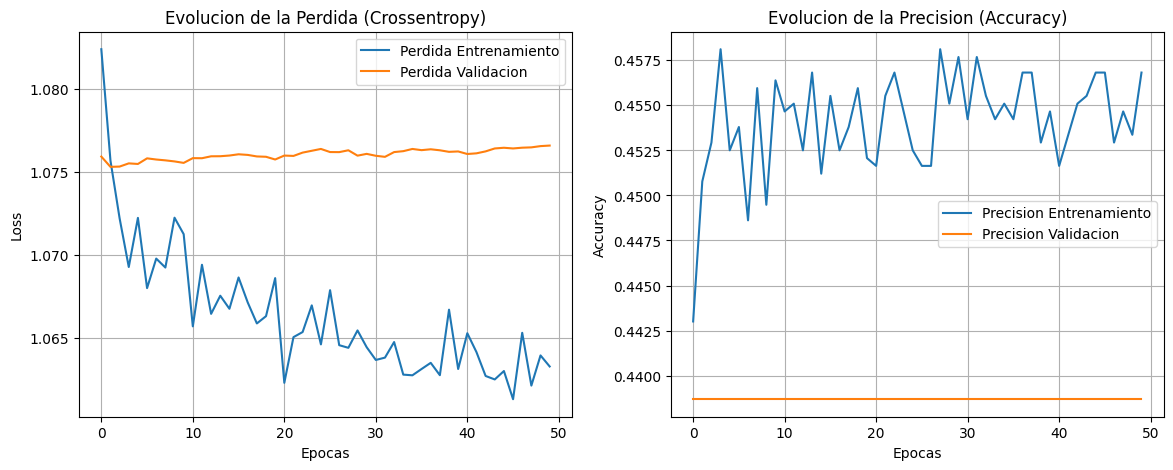

In [ ]:
#Configurar figura con dos subgraficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#Grafico de Perdida
ax1.plot(history.history['loss'], label='Perdida Entrenamiento')
ax1.plot(history.history['val_loss'], label='Perdida Validacion')
ax1.set_title('Evolucion de la Perdida (Crossentropy)')
ax1.set_xlabel('Epocas')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

#Grafico de Accuracy
ax2.plot(history.history['accuracy'], label='Accuracy Entrenamiento')
ax2.plot(history.history['val_accuracy'], label='Accuracy Validacion')
ax2.set_title('Evolucion del Accuracy')
ax2.set_xlabel('Epocas')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.show()

**Análisis de las curvas de entrenamiento:**
Los gráficos muestran que el Accuracy de validación se estabiliza rápidamente cerca del 44% y permanece prácticamente constante durante el resto de las épocas.
La pérdida de validación también se estabiliza y no presenta un aumento sostenido, por lo que no se observa una señal evidente de sobreajuste durante el entrenamiento.
Además, aumentar el número de épocas bajo esta configuración no genera una mejora visible en la precisión de validación. Por esta razón, se realizarán experimentos controlados modificando distintos parámetros del modelo para observar su efecto en el desempeño.

## 10. Experimento 1: Cambio de Optimizador a Adam

El modelo base utiliza el optimizador SGD. En este experimento cambiaremos el optimizador a Adam para observar si se producen diferencias en el entrenamiento y en las métricas finales.
Adam adapta la tasa de aprendizaje durante el entrenamiento. Para realizar una comparación controlada, mantendremos la misma arquitectura, Dropout de 0.2, 50 épocas y un batch size de 32, modificando únicamente el optimizador.

Como vimos en la teoría, Adam es un optimizador basado en gradiente estocástico que adapta la tasa de aprendizaje automáticamente, lo que frecuentemente ayuda a las redes a encontrar mejores patrones sin estancarse.

Para cumplir con la metodología de variar un parámetro a la vez, mantendremos intacta la arquitectura de capas, la regularización con Dropout (0.2) y la cantidad de épocas (50).

In [ ]:
tf.random.set_seed(42)

model_adam = models.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model_adam.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Entrenando modelo con optimizador Adam...")

history_adam = model_adam.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=0
)

print("Entrenamiento finalizado.")

y_pred_prob_adam = model_adam.predict(X_test)
y_pred_clases_adam = np.argmax(y_pred_prob_adam, axis=1)

print("\nReporte de Clasificación - Experimento 1 (Adam):")
print(classification_report(
    y_test,
    y_pred_clases_adam,
    target_names=['Visita (0)', 'Empate (1)', 'Local (2)']
))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando modelo con optimizador Adam...
Entrenamiento finalizado.
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Reporte de Clasificación - Experimento 1 (Adam):
              precision    recall  f1-score   support

  Visita (0)       0.00      0.00      0.00       219
  Empate (1)       0.00      0.00      0.00       174
   Local (2)       0.46      1.00      0.63       331

    accuracy                           0.46       724
   macro avg       0.15      0.33      0.21       724
weighted avg       0.21      0.46      0.29       724



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Análisis del Experimento 1 (Optimizador Adam):**
Al reemplazar SGD por Adam, las métricas finales se mantienen sin cambios. El modelo continúa prediciendo principalmente la clase Local y no logra identificar correctamente los empates ni las victorias visitantes.
Por lo tanto, cambiar el optimizador de SGD a Adam no produjo una mejora en el desempeño final del modelo bajo esta configuración.

## 11. Experimento 2: Cambio de Función de Activación



En este segundo experimento evaluaremos el efecto de modificar la función de activación de las capas ocultas de la red neuronal.

El modelo base utiliza ReLU. Para realizar una comparación controlada, mantendremos la misma arquitectura, optimizador, número de épocas, batch size y regularización, modificando únicamente la función de activación.

Se evaluarán las funciones ReLU, Tanh y Sigmoid. El objetivo es determinar si alguna de estas funciones permite obtener una mejor representación de los patrones presentes en los datos y mejorar la capacidad del modelo para diferenciar entre victoria visitante, empate y victoria local.

Este procedimiento permite analizar experimentalmente el impacto de las funciones de activación manteniendo constantes los demás parámetros del modelo.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def entrenar_modelo_activacion(activacion):
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)

    modelo = models.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(32, activation=activacion),
        layers.Dropout(0.2),
        layers.Dense(16, activation=activacion),
        layers.Dense(3, activation='softmax')
    ])

    modelo.compile(
        optimizer=SGD(learning_rate=0.01),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    historial = modelo.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        verbose=0
    )

    probabilidades = modelo.predict(X_test, verbose=0)
    predicciones = np.argmax(probabilidades, axis=1)

    metricas = {
        'Accuracy': accuracy_score(y_test, predicciones),
        'Precision': precision_score(y_test, predicciones, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, predicciones, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, predicciones, average='weighted', zero_division=0)
    }

    return modelo, historial, predicciones, metricas

La función anterior permite ejecutar el mismo procedimiento de entrenamiento utilizando distintas funciones de activación. De esta forma evitamos modificar simultáneamente otros hiperparámetros y podemos atribuir las diferencias observadas principalmente al cambio de función de activación.

Las métricas se calculan utilizando promedio ponderado (weighted) debido a que las clases pueden presentar distinta cantidad de observaciones. Esto permite que la contribución de cada clase considere su frecuencia dentro del conjunto de prueba.

In [ ]:
activaciones = ['relu', 'tanh', 'sigmoid']

resultados_activacion = {}
historiales_activacion = {}
predicciones_activacion = {}

for activacion in activaciones:
    modelo_exp, historial_exp, pred_exp, metricas_exp = entrenar_modelo_activacion(activacion)

    resultados_activacion[activacion] = metricas_exp
    historiales_activacion[activacion] = historial_exp
    predicciones_activacion[activacion] = pred_exp

tabla_activaciones = pd.DataFrame(resultados_activacion).T
tabla_activaciones

,Accuracy,Precision,Recall,F1-Score
relu,0.457182,0.209016,0.457182,0.286876
tanh,0.457182,0.209016,0.457182,0.286876
sigmoid,0.457182,0.209016,0.457182,0.286876


### Análisis del Experimento 2: Funciones de Activación

Los resultados obtenidos muestran que las tres funciones de activación evaluadas, ReLU, Tanh y Sigmoid, alcanzaron exactamente el mismo desempeño: un Accuracy de 45,72%, Precision de 20,90%, Recall de 45,72% y F1-Score de 28,69%.

Esto indica que modificar únicamente la función de activación no produjo una mejora en la capacidad de clasificación del modelo. A pesar de utilizar transformaciones matemáticas diferentes en las capas ocultas, las tres configuraciones terminaron convergiendo hacia un comportamiento equivalente.

El resultado refuerza la hipótesis observada en los experimentos anteriores: la principal limitación no parece encontrarse únicamente en el optimizador o en la función de activación, sino en la información disponible en las variables de entrada. Actualmente, el modelo recibe solamente los identificadores numéricos del equipo local y visitante, los cuales permiten distinguir los equipos, pero no representan directamente su rendimiento deportivo.

Por esta razón, continuaremos evaluando otros hiperparámetros, como el tamaño del batch, para determinar si cambios en el proceso de entrenamiento producen alguna mejora en el desempeño.

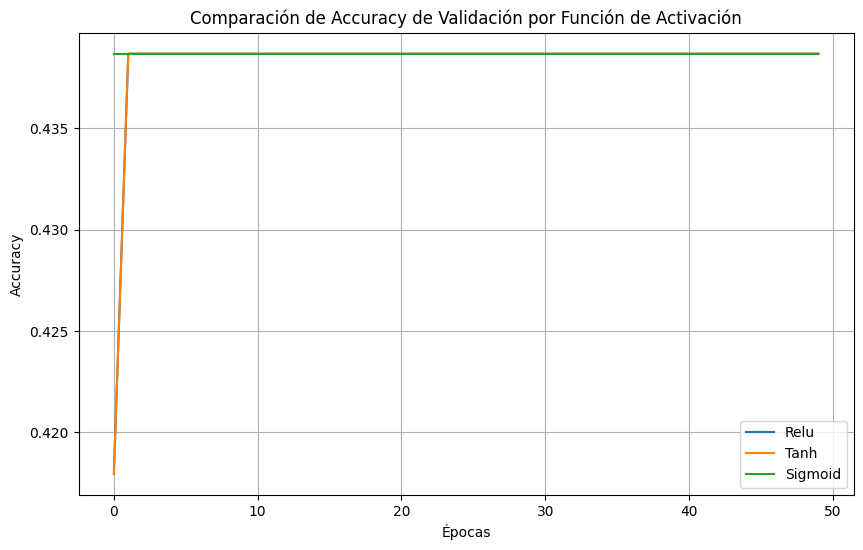

In [ ]:
plt.figure(figsize=(10, 6))

for activacion, historial in historiales_activacion.items():
    plt.plot(
        historial.history['val_accuracy'],
        label=activacion.capitalize()
    )

plt.title('Comparación de Accuracy de Validación por Función de Activación')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### Análisis de la convergencia según la función de activación

El gráfico muestra que las tres funciones de activación evaluadas convergen rápidamente hacia un Accuracy de validación cercano al 44%.

ReLU presenta una variación durante las primeras épocas, comenzando con un rendimiento inferior y alcanzando rápidamente el mismo nivel que Tanh y Sigmoid. Después de este ajuste inicial, las tres curvas permanecen prácticamente constantes durante el resto del entrenamiento.

Este comportamiento indica que aumentar la cantidad de épocas no genera una mejora adicional en la precisión de validación. Además, cambiar únicamente la función de activación no fue suficiente para modificar significativamente el comportamiento final de la red.

Al relacionar este gráfico con las métricas obtenidas en el conjunto de prueba, donde ReLU, Tanh y Sigmoid alcanzaron exactamente los mismos valores de Accuracy, Precision, Recall y F1-Score, se observa que las tres configuraciones terminaron generando un desempeño equivalente.

Esto sugiere que la principal limitación del modelo no se encuentra en la función de activación utilizada, sino posiblemente en la limitada información predictiva contenida en las variables de entrada.

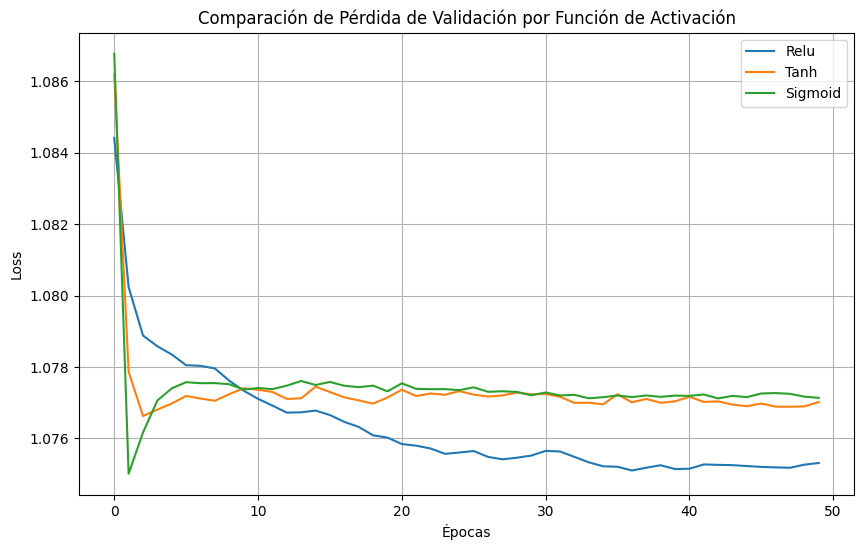

In [ ]:
plt.figure(figsize=(10, 6))

for activacion, historial in historiales_activacion.items():
    plt.plot(
        historial.history['val_loss'],
        label=activacion.capitalize()
    )

plt.title('Comparación de Pérdida de Validación por Función de Activación')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Análisis de la pérdida según la función de activación

A diferencia del Accuracy de validación, la función de pérdida permite observar pequeñas diferencias entre las funciones de activación.
Las tres configuraciones reducen rápidamente su pérdida durante las primeras épocas y posteriormente presentan un comportamiento estable. Aunque existen pequeñas diferencias entre sus curvas, estas no se traducen en cambios en las métricas finales de clasificación.

A pesar de estas diferencias, las tres funciones obtuvieron exactamente los mismos valores finales de Accuracy, Precision, Recall y F1-Score. Esto significa que las probabilidades generadas internamente por los modelos presentan diferencias, pero estas no fueron suficientes para modificar la clase seleccionada finalmente mediante `argmax`.

También se observa que las curvas de pérdida no aumentan progresivamente durante el entrenamiento, por lo que no existe una señal evidente de sobreajuste en este experimento. El principal comportamiento observado corresponde a un estancamiento temprano del aprendizaje.

Considerando conjuntamente las métricas y las curvas de entrenamiento, ReLU presenta una pérdida de validación ligeramente inferior, aunque esta ventaja no se traduce en una mejora de las métricas de clasificación. Por lo tanto, el experimento muestra que modificar la función de activación por sí sola no resuelve las limitaciones predictivas del modelo.

## 12. Experimento 3: Ajuste del Batch Size**


Luego de evaluar las funciones de activación, analizaremos otro hiperparámetro relevante: el tamaño del batch.

El batch_size determina cuántas observaciones procesa la red antes de actualizar sus pesos. Un batch pequeño realiza actualizaciones más frecuentes, mientras que uno más grande calcula actualizaciones utilizando una mayor cantidad de ejemplos simultáneamente.

Para realizar un experimento controlado utilizaremos la misma arquitectura y cambiaremos únicamente el batch size, evaluando los valores 16, 32 y 64.

In [ ]:
def entrenar_modelo_batch(batch_size):
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)

    modelo = models.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])

    modelo.compile(
        optimizer=SGD(learning_rate=0.01),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    historial = modelo.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=batch_size,
        verbose=0
    )

    probabilidades = modelo.predict(X_test, verbose=0)
    predicciones = np.argmax(probabilidades, axis=1)

    metricas = {
        'Accuracy': accuracy_score(y_test, predicciones),
        'Precision': precision_score(y_test, predicciones, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, predicciones, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, predicciones, average='weighted', zero_division=0)
    }

    return historial, predicciones, metricas

In [ ]:
batch_sizes = [16, 32, 64]

resultados_batch = {}
historiales_batch = {}

for batch_size in batch_sizes:
    historial_batch, pred_batch, metricas_batch = entrenar_modelo_batch(batch_size)

    resultados_batch[f'Batch {batch_size}'] = metricas_batch
    historiales_batch[f'Batch {batch_size}'] = historial_batch

tabla_batch = pd.DataFrame(resultados_batch).T
tabla_batch

,Accuracy,Precision,Recall,F1-Score
Batch 16,0.457182,0.209016,0.457182,0.286876
Batch 32,0.457182,0.209016,0.457182,0.286876
Batch 64,0.457182,0.209016,0.457182,0.286876


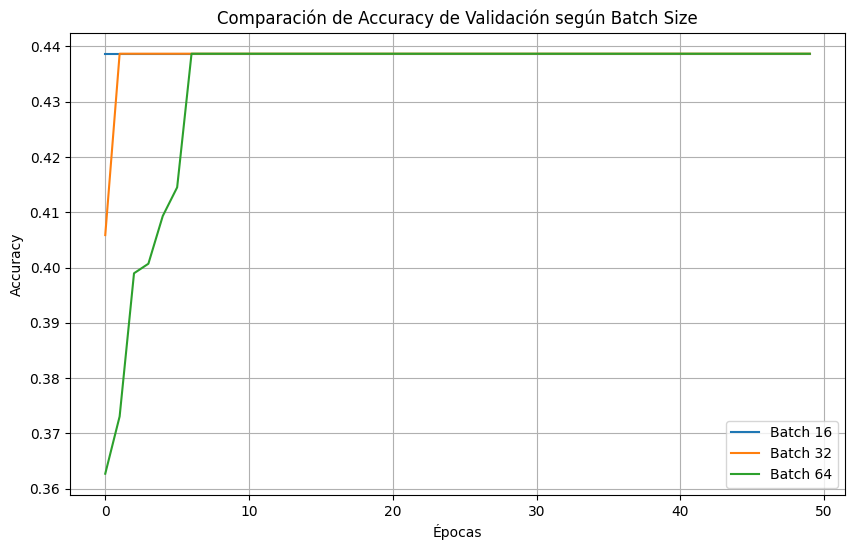

In [ ]:
plt.figure(figsize=(10, 6))

for nombre, historial in historiales_batch.items():
    plt.plot(
        historial.history['val_accuracy'],
        label=nombre
    )

plt.title('Comparación de Accuracy de Validación según Batch Size')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### Análisis del Experimento 3: Ajuste del Batch Size

Los resultados muestran que los tamaños de batch 16, 32 y 64 alcanzaron exactamente las mismas métricas finales en el conjunto de prueba: un Accuracy de 45,72%, Precision de 20,90%, Recall de 45,72% y F1-Score de 28,69%.

A pesar de obtener el mismo desempeño final, el gráfico de Accuracy de validación muestra diferencias durante las primeras épocas. El modelo con batch size 16 alcanza rápidamente un Accuracy cercano al 44%, mientras que batch size 32 requiere algunas actualizaciones adicionales y batch size 64 presenta una convergencia inicial más lenta.

Este comportamiento puede explicarse porque un batch más pequeño genera una mayor cantidad de actualizaciones de los pesos dentro de cada época, mientras que un batch más grande procesa más observaciones antes de realizar cada actualización.

Sin embargo, después de las primeras épocas las tres configuraciones convergen al mismo nivel y permanecen estables durante el resto del entrenamiento. Por lo tanto, modificar el tamaño del batch afectó principalmente la velocidad inicial de convergencia, pero no produjo una mejora en la capacidad final de clasificación.

Al relacionar este resultado con los experimentos anteriores, se observa nuevamente que modificar un hiperparámetro de entrenamiento no es suficiente para superar las limitaciones actuales del modelo. Esto refuerza la hipótesis de que las variables de entrada disponibles contienen una cantidad limitada de información predictiva sobre el resultado de los partidos.

## 13. Experimento 4: Impacto de Dropout


Hasta ahora hemos utilizado Dropout con una tasa de 0.2 como mecanismo de regularización. Para evaluar experimentalmente su efecto, compararemos dos modelos idénticos: uno sin Dropout y otro con Dropout de 0.2.

Dropout desactiva aleatoriamente una proporción de neuronas durante cada iteración de entrenamiento. Su propósito es reducir la dependencia excesiva entre neuronas y disminuir el riesgo de sobreajuste.

Para que la comparación sea válida, todos los demás parámetros permanecerán constantes.

In [ ]:
def entrenar_modelo_dropout(tasa_dropout):
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)

    capas_modelo = [
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(32, activation='relu')
    ]

    if tasa_dropout > 0:
        capas_modelo.append(layers.Dropout(tasa_dropout))

    capas_modelo.extend([
        layers.Dense(16, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])

    modelo = models.Sequential(capas_modelo)

    modelo.compile(
        optimizer=SGD(learning_rate=0.01),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    historial = modelo.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        verbose=0
    )

    probabilidades = modelo.predict(X_test, verbose=0)
    predicciones = np.argmax(probabilidades, axis=1)

    metricas = {
        'Accuracy': accuracy_score(y_test, predicciones),
        'Precision': precision_score(y_test, predicciones, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, predicciones, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, predicciones, average='weighted', zero_division=0)
    }

    return historial, metricas

In [ ]:
history_sin_dropout, metricas_sin_dropout = entrenar_modelo_dropout(0.0)
history_con_dropout, metricas_con_dropout = entrenar_modelo_dropout(0.2)

tabla_dropout = pd.DataFrame({
    'Sin Dropout': metricas_sin_dropout,
    'Dropout 0.2': metricas_con_dropout
}).T

tabla_dropout

,Accuracy,Precision,Recall,F1-Score
Sin Dropout,0.457182,0.209016,0.457182,0.286876
Dropout 0.2,0.457182,0.209016,0.457182,0.286876


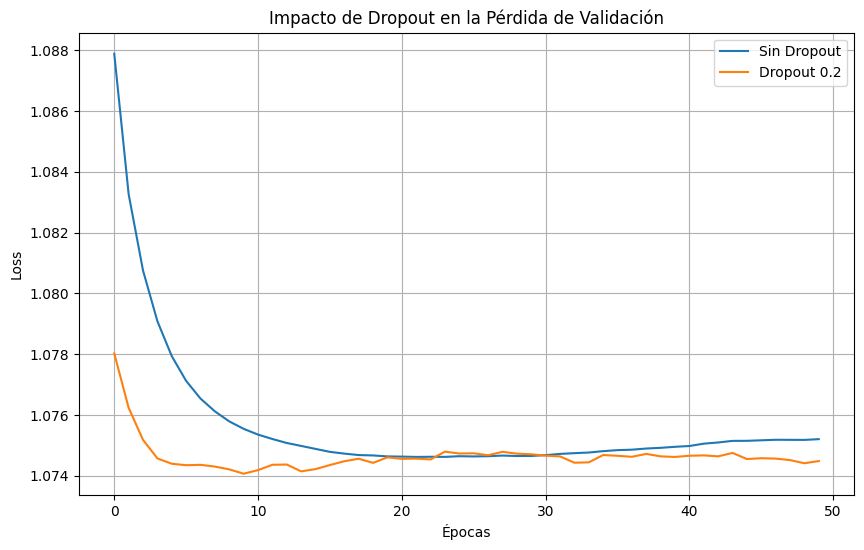

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_sin_dropout.history['val_loss'],
    label='Sin Dropout'
)

plt.plot(
    history_con_dropout.history['val_loss'],
    label='Dropout 0.2'
)

plt.title('Impacto de Dropout en la Pérdida de Validación')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Análisis del Experimento 4: Impacto de Dropout

Los resultados muestran que utilizar Dropout con una tasa de 0.2 o eliminar completamente esta técnica de regularización produce las mismas métricas finales en el conjunto de prueba: Accuracy de 45,72%, Precision de 20,90%, Recall de 45,72% y F1-Score de 28,69%.

Sin embargo, al analizar la pérdida de validación se observan diferencias durante el proceso de entrenamiento. El modelo con Dropout 0.2 alcanza rápidamente valores bajos de pérdida y posteriormente mantiene un comportamiento relativamente estable. En cambio, el modelo sin Dropout comienza con una pérdida superior y necesita más épocas para aproximarse a valores similares.

A pesar de esta diferencia en la dinámica del entrenamiento, la regularización mediante Dropout no produjo una mejora en las métricas finales de clasificación. Esto indica que, para la arquitectura y los datos utilizados, reducir la dependencia entre neuronas no fue suficiente para mejorar la capacidad predictiva del modelo.

Además, las curvas no muestran una separación creciente ni un aumento pronunciado de la pérdida de validación que permita identificar un problema evidente de sobreajuste. Por esta razón, los resultados sugieren que el principal problema del modelo no corresponde al sobreajuste que Dropout intenta reducir, sino a la limitada información predictiva disponible en las variables de entrada.

En conclusión, Dropout 0.2 modifica el comportamiento inicial del entrenamiento y mantiene una pérdida de validación estable, pero no genera una mejora observable en Accuracy, Precision, Recall o F1-Score.

Experimento complementario: Comparación de funciones de pérdida
Para complementar los experimentos anteriores, se compararán dos funciones de pérdida: sparse_categorical_crossentropy, utilizada en el modelo base, y mean_squared_error.
Se mantendrán la misma arquitectura, optimizador, número de épocas, batch size y Dropout, modificando únicamente la función de pérdida. El objetivo es observar si este cambio produce diferencias en el entrenamiento y en las métricas finales.

In [ ]:
from tensorflow.keras.optimizers import SGD

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

modelo_cross = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax')
])

modelo_cross.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

hist_cross = modelo_cross.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=0
)

pred_cross = np.argmax(modelo_cross.predict(X_test, verbose=0), axis=1)

In [ ]:
y_train_mse = tf.keras.utils.to_categorical(y_train, 3)

tf.keras.backend.clear_session()
tf.random.set_seed(42)

modelo_mse = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax')
])

modelo_mse.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='mean_squared_error',
    metrics=['accuracy']
)

hist_mse = modelo_mse.fit(
    X_train, y_train_mse,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=0
)

pred_mse = np.argmax(modelo_mse.predict(X_test, verbose=0), axis=1)

In [ ]:
resultados_loss = {
    'Crossentropy': [
        accuracy_score(y_test, pred_cross),
        precision_score(y_test, pred_cross, average='weighted', zero_division=0),
        recall_score(y_test, pred_cross, average='weighted', zero_division=0),
        f1_score(y_test, pred_cross, average='weighted', zero_division=0)
    ],
    'MSE': [
        accuracy_score(y_test, pred_mse),
        precision_score(y_test, pred_mse, average='weighted', zero_division=0),
        recall_score(y_test, pred_mse, average='weighted', zero_division=0),
        f1_score(y_test, pred_mse, average='weighted', zero_division=0)
    ]
}

tabla_loss = pd.DataFrame(
    resultados_loss,
    index=['Accuracy', 'Precision', 'Recall', 'F1-Score']
)

tabla_loss

,Crossentropy,MSE
Accuracy,0.457182,0.457182
Precision,0.209016,0.209016
Recall,0.457182,0.457182
F1-Score,0.286876,0.286876


In [ ]:
import matplotlib.pyplot as plt

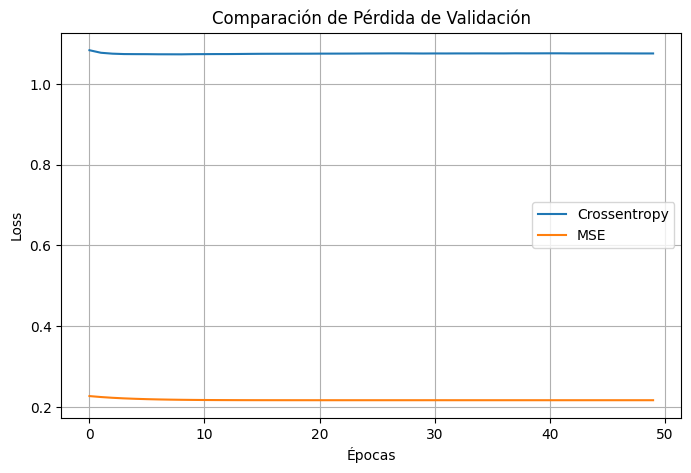

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(hist_cross.history['val_loss'], label='Crossentropy')
plt.plot(hist_mse.history['val_loss'], label='MSE')

plt.title('Comparación de Pérdida de Validación')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Análisis del experimento de funciones de pérdida

Los resultados muestran que Crossentropy y MSE obtuvieron los mismos valores de Accuracy, Precision, Recall y F1-Score. Esto indica que, para este modelo y conjunto de datos, cambiar la función de pérdida no produjo una diferencia en el resultado final de clasificación.

En el gráfico se observa que ambas funciones disminuyen durante las primeras épocas y luego se estabilizan. Los valores de Loss no se comparan directamente entre sí, ya que cada función utiliza una escala diferente.

Por lo tanto, en este experimento ninguna de las dos funciones produjo una mejora en las métricas de clasificación. El comportamiento obtenido también es consistente con los experimentos anteriores, donde los cambios de configuración no modificaron el resultado final del modelo.

## **14. Tabla Comparativa General**

Para resumir los experimentos realizados construiremos una tabla con Accuracy, Precision, Recall y F1-Score.

La comparación de las funciones de pérdida Crossentropy y MSE se presenta además en una tabla específica, debido a que corresponde a un experimento separado.

Esto permite comparar las configuraciones utilizando múltiples métricas en lugar de depender exclusivamente del accuracy.

In [ ]:
y_pred_base_prob = model.predict(X_test, verbose=0)
y_pred_base = np.argmax(y_pred_base_prob, axis=1)

metricas_base = {
    'Accuracy': accuracy_score(y_test, y_pred_base),
    'Precision': precision_score(y_test, y_pred_base, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_base, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_base, average='weighted', zero_division=0)
}

metricas_adam = {
    'Accuracy': accuracy_score(y_test, y_pred_clases_adam),
    'Precision': precision_score(y_test, y_pred_clases_adam, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_clases_adam, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_clases_adam, average='weighted', zero_division=0)
}

tabla_general = pd.DataFrame({
    'Modelo Base - SGD': metricas_base,
    'Adam': metricas_adam,
    'ReLU': resultados_activacion['relu'],
    'Tanh': resultados_activacion['tanh'],
    'Sigmoid': resultados_activacion['sigmoid'],
    'Batch 16': resultados_batch['Batch 16'],
    'Batch 32': resultados_batch['Batch 32'],
    'Batch 64': resultados_batch['Batch 64'],
    'Sin Dropout': metricas_sin_dropout,
    'Dropout 0.2': metricas_con_dropout
}).T

tabla_general = tabla_general.round(4)
tabla_general

,Accuracy,Precision,Recall,F1-Score
Modelo Base - SGD,0.4572,0.209,0.4572,0.2869
Adam,0.4572,0.209,0.4572,0.2869
ReLU,0.4572,0.209,0.4572,0.2869
Tanh,0.4572,0.209,0.4572,0.2869
Sigmoid,0.4572,0.209,0.4572,0.2869
Batch 16,0.4572,0.209,0.4572,0.2869
Batch 32,0.4572,0.209,0.4572,0.2869
Batch 64,0.4572,0.209,0.4572,0.2869
Sin Dropout,0.4572,0.209,0.4572,0.2869
Dropout 0.2,0.4572,0.209,0.4572,0.2869


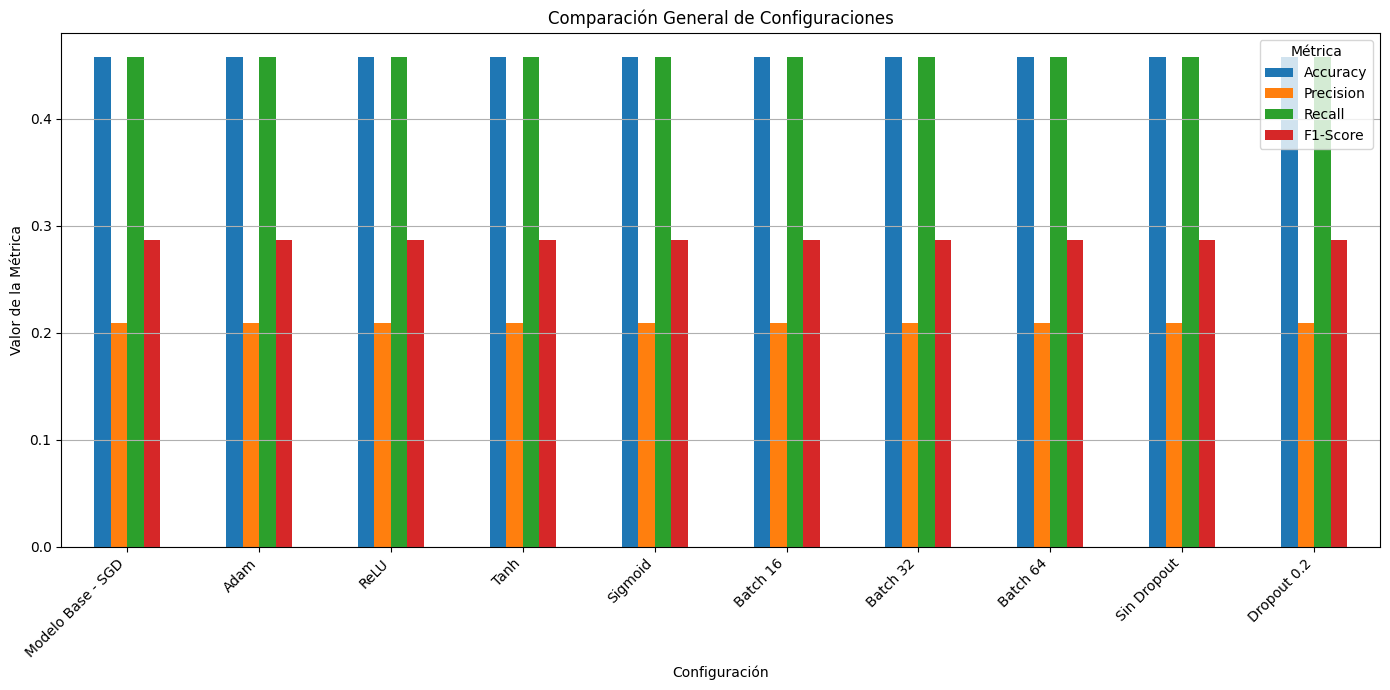

In [ ]:
tabla_general.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Comparación General de Configuraciones')
plt.xlabel('Configuración')
plt.ylabel('Valor de la Métrica')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Métrica')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### 15. Análisis Comparativo General

La comparación general muestra que todas las configuraciones evaluadas alcanzaron las mismas métricas finales en el conjunto de prueba: Accuracy de 45,72%, Precision de 20,90%, Recall de 45,72% y F1-Score de 28,69%.

Durante la experimentación se modificaron de forma controlada distintos componentes del modelo. Se compararon los optimizadores SGD y Adam, las funciones de activación ReLU, Tanh y Sigmoid, los tamaños de batch de 16, 32 y 64, el uso de Dropout con una tasa de 0.2 frente a un modelo sin esta técnica y las funciones de pérdida Crossentropy y MSE.

Aunque algunos experimentos presentaron diferencias en la velocidad de convergencia y en la pérdida de validación, ninguno consiguió modificar las métricas finales de clasificación.

En el caso de las funciones de pérdida, Crossentropy y MSE también obtuvieron exactamente los mismos valores de Accuracy, Precision, Recall y F1-Score. Por esta razón, no se observa una mejora en la clasificación al cambiar una función de pérdida por la otra.

La diferencia entre Accuracy y Precision/F1-Score también evidencia que el Accuracy por sí solo no representa adecuadamente el desempeño del modelo. El modelo alcanza aproximadamente un 45,72% de aciertos globales, pero presenta valores considerablemente menores de Precision y F1-Score.

En conjunto, los experimentos respaldan la conclusión de que la principal limitación se encuentra en la información disponible en las variables utilizadas. El modelo recibe únicamente los identificadores codificados del equipo local y visitante, sin información adicional sobre el rendimiento deportivo previo de cada equipo.

Por lo tanto, continuar modificando exclusivamente los hiperparámetros de esta arquitectura probablemente produciría mejoras limitadas. Una evolución del modelo debería enfocarse principalmente en enriquecer las variables de entrada utilizando información histórica disponible antes de cada partido.

## 16. Selección de la Configuración Final

Los experimentos no identificaron una configuración claramente superior en términos de las métricas finales de clasificación, ya que todas alcanzaron los mismos valores de Accuracy, Precision, Recall y F1-Score.

Esto también se observó al comparar las funciones de pérdida Crossentropy y MSE, que obtuvieron exactamente los mismos resultados en las métricas de clasificación.

Por esta razón, no corresponde seleccionar una configuración únicamente a partir del valor máximo de estas métricas. Para establecer una configuración final se consideran también el comportamiento durante el entrenamiento, la complejidad del modelo y los resultados observados en las curvas de validación.

Se mantendrá el modelo base con SGD, activación ReLU, batch size 32 y Dropout 0.2 como configuración de referencia final. Esta elección no implica que haya obtenido mejores métricas que las demás configuraciones, sino que permite mantener una configuración simple y estable como referencia para analizar las limitaciones del modelo.

## 17. Limitaciones del Modelo

Los resultados obtenidos permiten identificar que la principal limitación del modelo se encuentra en las características utilizadas como entrada.

Actualmente, la red neuronal recibe únicamente dos variables: el identificador codificado del equipo local y el identificador codificado del equipo visitante. Estas variables permiten distinguir qué equipos participan en un partido, pero no describen directamente su rendimiento deportivo.

Además, los valores generados mediante LabelEncoder deben interpretarse únicamente como identificadores numéricos. La diferencia matemática entre los códigos asignados a dos equipos no representa necesariamente una diferencia real en su nivel deportivo.

Por ejemplo, el modelo no conoce información como la posición de cada equipo en la tabla, resultados de partidos anteriores, promedio de goles, rendimiento como local o visitante, racha reciente o historial de enfrentamientos entre ambos equipos.

Los experimentos realizados demostraron que modificar el optimizador, las funciones de activación, el tamaño del batch, Dropout y la función de pérdida no fue suficiente para mejorar las métricas finales de clasificación.

Una futura versión del modelo debería incorporar características históricas calculadas exclusivamente utilizando información disponible antes de cada partido. Esto permitiría entregar a la red variables con mayor capacidad predictiva sin introducir información del resultado que se intenta predecir.

## 18. Conclusiones

En este proyecto se desarrolló una red neuronal multicapa orientada a la clasificación de resultados de partidos de la Primera División de Chile en tres categorías: victoria visitante, empate y victoria local.

El proceso comenzó con la preparación de los datos y la construcción de la variable objetivo a partir del resultado histórico de cada encuentro. Posteriormente, las variables utilizadas para generar dicha clasificación fueron eliminadas de las entradas del modelo para evitar data leakage.

Los equipos fueron transformados a identificadores numéricos y las variables de entrada fueron estandarizadas antes del entrenamiento. Se implementó una arquitectura MLP compuesta por capas Dense, funciones de activación, regularización mediante Dropout y una capa de salida Softmax de tres neuronas.

A partir del modelo base se desarrollaron experimentos controlados modificando el optimizador, la función de activación, el tamaño del batch, la utilización de Dropout y la función de pérdida. El desempeño fue evaluado mediante Accuracy, Precision, Recall y F1-Score, además de curvas de entrenamiento y pérdida de validación.

Las configuraciones evaluadas alcanzaron las mismas métricas finales: Accuracy de 45,72%, Precision de 20,90%, Recall de 45,72% y F1-Score de 28,69%. La comparación entre Crossentropy y MSE también presentó exactamente los mismos resultados en estas métricas.

Los gráficos permitieron observar diferencias en aspectos como la velocidad de convergencia y la evolución de la pérdida, pero estos cambios no fueron suficientes para mejorar la clasificación final.

Estos resultados muestran que modificar exclusivamente los hiperparámetros evaluados no fue suficiente para mejorar la capacidad de clasificación. La experimentación permitió identificar que una de las principales limitaciones corresponde a la información disponible en las variables de entrada.

Actualmente, utilizar únicamente la identidad del equipo local y visitante entrega poca información sobre el estado deportivo de cada equipo antes de un encuentro. Como mejora futura se propone incorporar características históricas como rendimiento reciente, posición en la tabla, promedio de goles, rendimiento como local y visitante e historial de enfrentamientos.

En conclusión, los experimentos permitieron evaluar de forma controlada diferentes decisiones de diseño y entrenamiento de la red neuronal. Aunque los ajustes realizados no mejoraron las métricas finales, los resultados entregaron evidencia útil para identificar las limitaciones del enfoque actual y definir mejoras fundamentadas para una futura versión del modelo.